#**Titanic Survival Analysis**
**Name:** Ayush Kumar

**Course / Batch:** Maincraft (01 September) (2026-2027)

**AICTE Student Id:** STU6a624b1fd56521784826655

#**Problem Statement**

On April 15, 1912, the RMS Titanic sank after colliding with an iceberg, resulting in the deaths of 1,502 out of 2,224 passengers and crew. While survival involved an element of luck, specific demographic and socioeconomic groups had significantly higher survival rates than others.

The objective of this project is to perform an Exploratory Data Analysis (EDA) on the Titanic dataset to clean the data, identify key patterns influencing survival, and visualize how factors such as gender, passenger class, age, and family structure impacted a passenger's likelihood of survival.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv('train.csv')

# Preview data
print("--- First 5 Rows ---")
display(df.head())

print("\n--- Summary Info ---")
df.info()

--- First 5 Rows ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



--- Summary Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Impute missing 'Age' values with median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Create Age Groups for analysis
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child (0-12)', 'Teens (13-18)', 'Young Adult (19-35)', 'Adult (36-60)', 'Senior (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

print("\nMissing values in Age after imputation:", df['Age'].isnull().sum())

Missing values before cleaning:
Age         177
Cabin       687
Embarked      2
dtype: int64

Missing values in Age after imputation: 0


/tmp/ipykernel_1889/866067868.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [9]:
# Extract title using regular expressions
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Group rare titles
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# Print survival rate by Title
print(df.groupby('Title')['Survived'].mean() * 100)

Title
Master    57.500000
Miss      70.270270
Mr        15.667311
Mrs       79.365079
Rare      34.782609
Name: Survived, dtype: float64


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1889/1517852379.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [4]:
# 1. Survival Rate by Gender
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print("--- 1. Survival Rate by Gender ---")
for sex, rate in gender_survival.items():
    print(f"{sex.capitalize()}: {rate:.2f}%")

# 2. Survival Rate by Passenger Class
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
print("\n--- 2. Survival Rate by Passenger Class ---")
for pclass, rate in class_survival.items():
    print(f"Class {pclass}: {rate:.2f}%")

# 3. Survival Rate by Age Group
age_survival = df.groupby('AgeGroup', observed=False)['Survived'].mean() * 100
print("\n--- 3. Survival Rate by Age Group ---")
for age_grp, rate in age_survival.items():
    print(f"{age_grp}: {rate:.2f}%")

--- 1. Survival Rate by Gender ---
Female: 74.20%
Male: 18.89%

--- 2. Survival Rate by Passenger Class ---
Class 1: 62.96%
Class 2: 47.28%
Class 3: 24.24%

--- 3. Survival Rate by Age Group ---
Child (0-12): 57.97%
Teens (13-18): 42.86%
Young Adult (19-35): 35.33%
Adult (36-60): 40.00%
Senior (60+): 22.73%


In [10]:
# Total family members onboard
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Flag if passenger was traveling alone
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Survival comparison
print("Survival Rate - Solo vs Family:")
print(df.groupby('IsAlone')['Survived'].mean() * 100)

Survival Rate - Solo vs Family:
IsAlone
0    50.564972
1    30.353818
Name: Survived, dtype: float64


/tmp/ipykernel_1889/445017180.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df, palette="Set2")


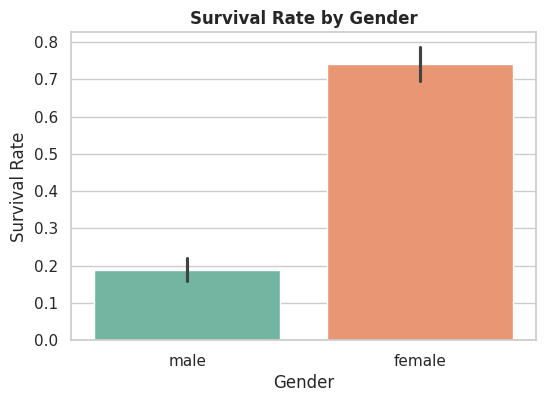

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.barplot(x="Sex", y="Survived", data=df, palette="Set2")
plt.title("Survival Rate by Gender", fontsize=12, fontweight="bold")
plt.ylabel("Survival Rate")
plt.xlabel("Gender")
plt.show()

/tmp/ipykernel_1889/4076204185.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df, palette="Blues_d")


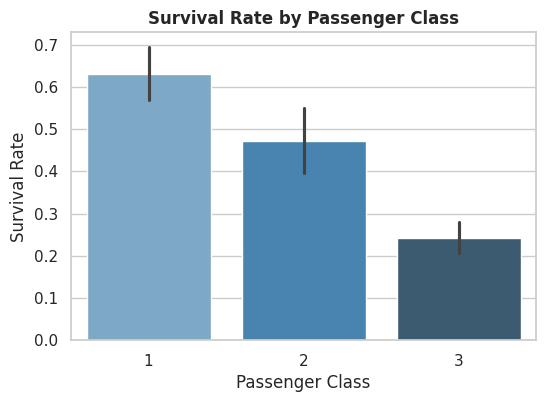

In [6]:
plt.figure(figsize=(6, 4))
sns.barplot(x="Pclass", y="Survived", data=df, palette="Blues_d")
plt.title("Survival Rate by Passenger Class", fontsize=12, fontweight="bold")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.show()

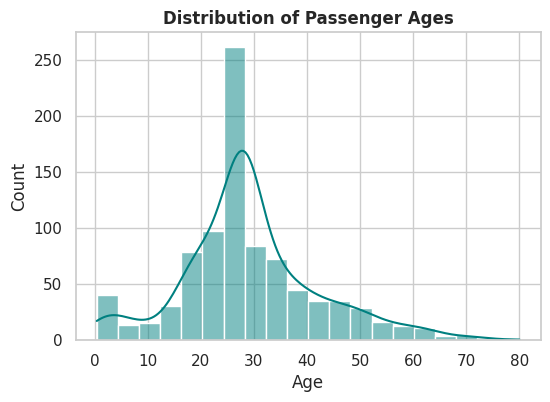

In [7]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Age"], kde=True, bins=20, color="teal")
plt.title("Distribution of Passenger Ages", fontsize=12, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_1889/1966658389.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AgeGroup", y="Survived", data=df, palette="Purples_d")


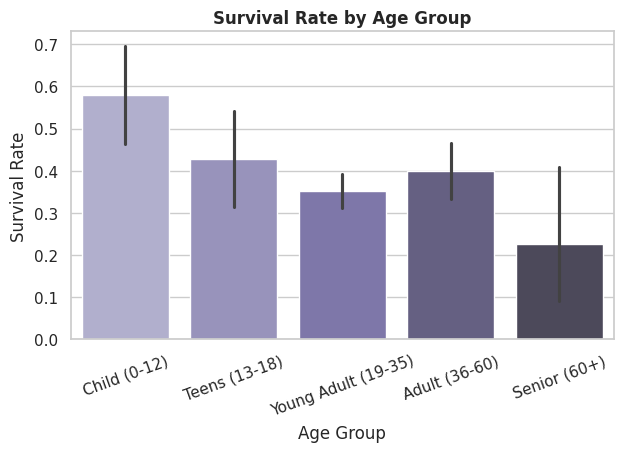

In [8]:
# Bin age into categories
bins = [0, 12, 18, 35, 60, 100]
labels = [
    "Child (0-12)",
    "Teens (13-18)",
    "Young Adult (19-35)",
    "Adult (36-60)",
    "Senior (60+)",
]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

plt.figure(figsize=(7, 4))
sns.barplot(x="AgeGroup", y="Survived", data=df, palette="Purples_d")
plt.title("Survival Rate by Age Group", fontsize=12, fontweight="bold")
plt.ylabel("Survival Rate")
plt.xlabel("Age Group")
plt.xticks(rotation=20)
plt.show()

/tmp/ipykernel_1889/591033508.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, palette='Set2')


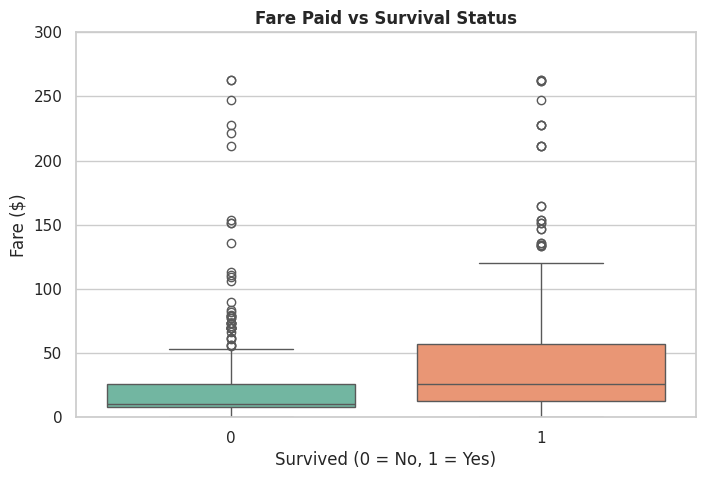

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Survived', y='Fare', data=df, palette='Set2')
plt.title('Fare Paid vs Survival Status', fontweight='bold')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare ($)')
plt.ylim(0, 300) # Limit outlier zoom
plt.show()

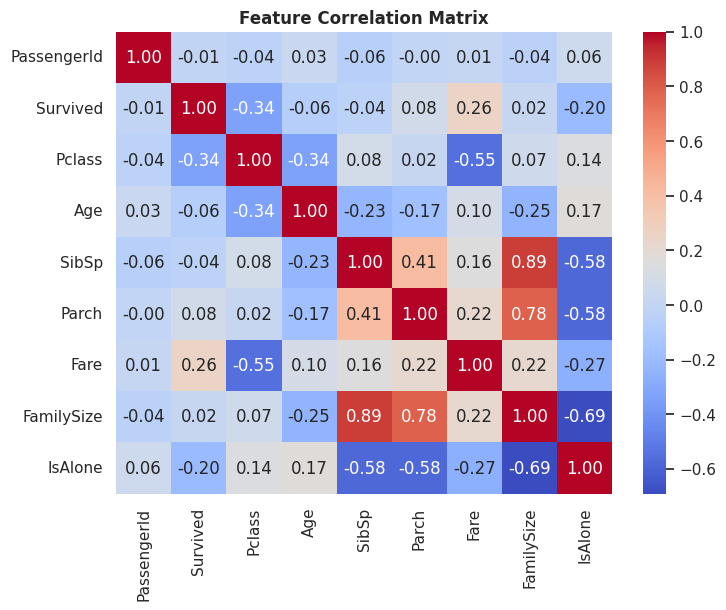

In [12]:
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.show()

### **Conclusion**

This Exploratory Data Analysis (EDA) on the Titanic dataset highlights several key factors that determined passenger survival during the tragedy:

1. **Gender Was the Strongest Survival Determinant:**
Female passengers had a survival rate of **74.20%**, compared to just **18.89%** for male passengers. This reflects the strict enforcement of the "women and children first" evacuation protocol.


2. **Socioeconomic Status Heavily Influenced Outcomes:**
Passengers in **1st Class** had the highest survival rate (**62.96%**), whereas **3rd Class** passengers had the lowest (**24.24%**). Proximity to the top deck and priority access to lifeboats played a major role in survival.


3. **Age Impacted Survival Probabilities:**
Children aged 0–12 had the highest survival rate among all age groups at **57.97%**. Conversely, seniors aged 60 and older had the lowest survival rate at **22.73%**.


4. **Family Presence Improved Chances:**
Passengers traveling with family members survived at higher rates (**50.57%**) compared to solo travelers (**30.35%**), demonstrating that social support systems assisted during the evacuation.


The analysis demonstrates that survival on the Titanic was not purely random; it was strongly dictated by demographic privileges, socioeconomic status, and evacuation protocols.